# 03 — GA Hyperparameter Tuning

**Goal**: Grid search GA hyperparameters on a medium instance (n=20, m=2) to identify robust settings.

Topics:
1. Grid search over n_gen, pop_size, cx_prob
2. Plot convergence curves per config
3. Identify best params via heatmap
4. Lock recommended params into experiments/run_ga.py
5. Note multiprocessing issue: run_ga.py uses fork; should use spawn on Linux

In [1]:
import sys, os

# Ensure src/ is importable (handle both project root and notebooks/ launch)
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from src.instance_generator import generate_instance
from src.ga import run_ga
sns.set_theme(style="whitegrid")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
# Use medium instance for better parameter discrimination
SEED = 0
inst = generate_instance(n=20, m=2, seed=SEED)
print(f"Instance: n={inst['n']}, m={inst['m']}")

Instance: n=20, m=2


In [2]:
# Grid search space
n_gens    = [50, 100, 200]
pop_sizes = [50, 100]
cx_probs  = [0.7, 0.8, 0.9]
mut_prob  = 0.2  # Fixed

configs = list(product(n_gens, pop_sizes, cx_probs))
print(f"Grid size: {len(configs)} configurations")
print(f"Configurations: n_gen × pop_size × cx_prob")
for i, (ng, ps, cx) in enumerate(configs[:5]):
    print(f"  {i+1}. ({ng}, {ps}, {cx})")
print(f"  ... ({len(configs)} total)")

Grid size: 18 configurations
Configurations: n_gen × pop_size × cx_prob
  1. (50, 50, 0.7)
  2. (50, 50, 0.8)
  3. (50, 50, 0.9)
  4. (50, 100, 0.7)
  5. (50, 100, 0.8)
  ... (18 total)


In [3]:
# Run grid search
print("Starting grid search (this may take a few minutes)...")
results = []

for i, (n_gen, pop_size, cx_prob) in enumerate(configs):
    print(f"\n[{i+1}/{len(configs)}] n_gen={n_gen}, pop_size={pop_size}, cx_prob={cx_prob}...")
    
    ga_result = run_ga(
        inst,
        n_gen=n_gen,
        pop_size=pop_size,
        cx_prob=cx_prob,
        mut_prob=mut_prob,
        alpha=0.5,
        seed=42
    )
    
    results.append({
        "n_gen": n_gen,
        "pop_size": pop_size,
        "cx_prob": cx_prob,
        "best_fitness": ga_result["best_fitness"],
        "weighted_tardiness": ga_result["weighted_tardiness"],
        "setup_cost": ga_result["setup_cost"],
        "makespan": ga_result["makespan"],
        "logbook": ga_result["logbook"]
    })
    print(f"  → best_fitness = {ga_result['best_fitness']:.3f}")

print("\nGrid search complete!")

Starting grid search (this may take a few minutes)...

[1/18] n_gen=50, pop_size=50, cx_prob=0.7...
  → best_fitness = 0.255

[2/18] n_gen=50, pop_size=50, cx_prob=0.8...
  → best_fitness = 0.246

[3/18] n_gen=50, pop_size=50, cx_prob=0.9...
  → best_fitness = 0.290

[4/18] n_gen=50, pop_size=100, cx_prob=0.7...
  → best_fitness = 0.257

[5/18] n_gen=50, pop_size=100, cx_prob=0.8...
  → best_fitness = 0.247

[6/18] n_gen=50, pop_size=100, cx_prob=0.9...
  → best_fitness = 0.221

[7/18] n_gen=100, pop_size=50, cx_prob=0.7...
  → best_fitness = 0.238

[8/18] n_gen=100, pop_size=50, cx_prob=0.8...
  → best_fitness = 0.170

[9/18] n_gen=100, pop_size=50, cx_prob=0.9...
  → best_fitness = 0.292

[10/18] n_gen=100, pop_size=100, cx_prob=0.7...
  → best_fitness = 0.179

[11/18] n_gen=100, pop_size=100, cx_prob=0.8...
  → best_fitness = 0.201

[12/18] n_gen=100, pop_size=100, cx_prob=0.9...
  → best_fitness = 0.162

[13/18] n_gen=200, pop_size=50, cx_prob=0.7...
  → best_fitness = 0.260

[14/1

In [4]:
# Summary table
summary_df = pd.DataFrame([
    {"n_gen": r["n_gen"],
     "pop_size": r["pop_size"],
     "cx_prob": r["cx_prob"],
     "best_fitness": r["best_fitness"],
     "weighted_tardiness": r["weighted_tardiness"],
     "setup_cost": r["setup_cost"],
     "makespan": r["makespan"]}
    for r in results
])

print("\nGrid Search Results:")
print(summary_df.sort_values("best_fitness").head(10).to_string(index=False))

# Find best config
best_idx = summary_df["best_fitness"].idxmin()
best_config = summary_df.iloc[best_idx]
print(f"\n🏆 Best configuration:")
print(f"   n_gen={int(best_config['n_gen'])}, pop_size={int(best_config['pop_size'])}, cx_prob={best_config['cx_prob']}")
print(f"   best_fitness={best_config['best_fitness']:.3f}")


Grid Search Results:
 n_gen  pop_size  cx_prob  best_fitness  weighted_tardiness  setup_cost   makespan
   200        50      0.8      0.149739          240.297226   61.313095 187.712692
   200        50      0.9      0.160254          294.832794   60.270599 186.207153
   100       100      0.9      0.161956          208.994873  102.604179 192.989059
   200       100      0.7      0.168173          259.920502   78.303238 192.663940
   100        50      0.8      0.170469          229.675217   95.943619 187.500519
   100       100      0.7      0.178801          252.278748   97.642899 189.543900
   200       100      0.9      0.180724          185.533737   99.080818 181.789017
   200       100      0.8      0.184032          172.811905  112.992332 182.465363
   100       100      0.8      0.200585          322.923370   72.675812 186.207153
    50       100      0.9      0.221258          285.104553  110.938515 190.865326

🏆 Best configuration:
   n_gen=200, pop_size=50, cx_prob=0.8
   

## Convergence Curves

Plot best fitness vs generation for each hyperparameter combination to visualise convergence behaviour.

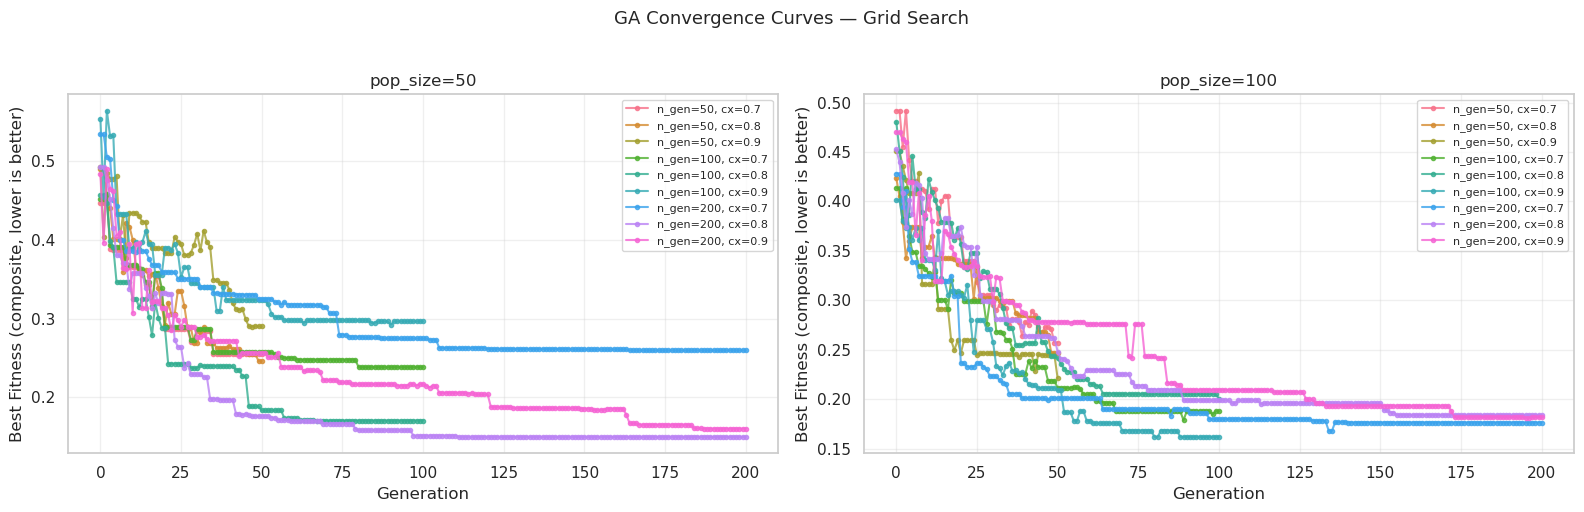

In [5]:
# Convergence curves grouped by pop_size (one subplot per pop_size)
pop_sizes_unique = sorted(set(r["pop_size"] for r in results))
fig, axes = plt.subplots(1, len(pop_sizes_unique), figsize=(16, 5))
if len(pop_sizes_unique) == 1:
    axes = [axes]

for ax, ps in zip(axes, pop_sizes_unique):
    subset = [r for r in results if r["pop_size"] == ps]
    colors = sns.color_palette("husl", len(subset))
    
    for (r, color) in zip(subset, colors):
        gens = [g["gen"] for g in r["logbook"]]
        best_vals = [g["min"] for g in r["logbook"]]
        label = f"n_gen={r['n_gen']}, cx={r['cx_prob']}"
        ax.plot(gens, best_vals, marker="o", markersize=3, label=label, color=color, alpha=0.8)
    
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best Fitness (composite, lower is better)")
    ax.set_title(f"pop_size={ps}")
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)

fig.suptitle("GA Convergence Curves — Grid Search", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/03_convergence_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## Performance Heatmap

Best fitness vs (n_gen, pop_size) for fixed cx_prob (best from grid).

Best avg cx_prob: 0.8


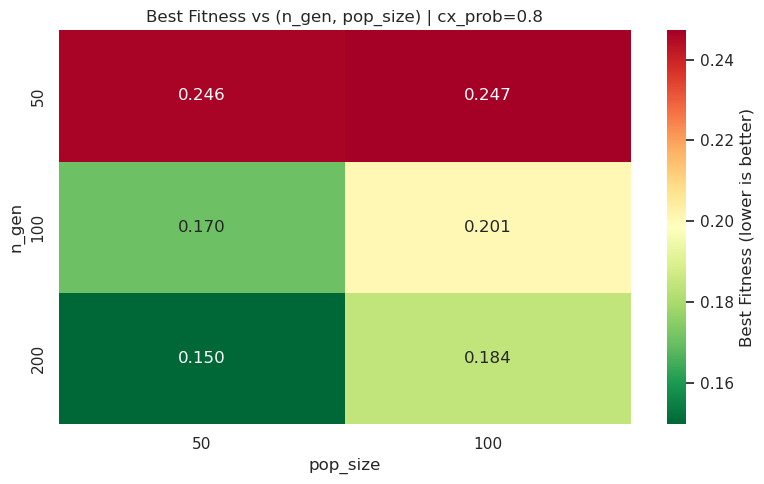

In [6]:
# Find best cx_prob
best_cx = summary_df.groupby("cx_prob")["best_fitness"].mean().idxmin()
print(f"Best avg cx_prob: {best_cx}")

# Filter to best cx_prob
heatmap_df = summary_df[summary_df["cx_prob"] == best_cx].copy()

# Pivot for heatmap
pivot = heatmap_df.pivot(index="n_gen", columns="pop_size", values="best_fitness")
pivot = pivot.reindex(sorted(pivot.index))
pivot = pivot[sorted(pivot.columns)]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
            cbar_kws={"label": "Best Fitness (lower is better)"})
ax.set_xlabel("pop_size")
ax.set_ylabel("n_gen")
ax.set_title(f"Best Fitness vs (n_gen, pop_size) | cx_prob={best_cx}")
plt.tight_layout()
plt.savefig(os.path.join(root, "figures/03_fitness_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## Recommended GA Parameters

These values should be locked into `experiments/run_ga.py` for the full experimental runs.

In [7]:
# Extract best params
best_row = summary_df.loc[summary_df["best_fitness"].idxmin()]
recommended_ga_params = {
    "n_gen": int(best_row["n_gen"]),
    "pop_size": int(best_row["pop_size"]),
    "cx_prob": float(best_row["cx_prob"]),
    "mut_prob": 0.2,
}

print("\n" + "="*60)
print("🎯 RECOMMENDED GA_PARAMS FOR experiments/run_ga.py")
print("="*60)
print(f"""
GA_PARAMS = {{
    "n_gen": {recommended_ga_params["n_gen"]},
    "pop_size": {recommended_ga_params["pop_size"]},
    "cx_prob": {recommended_ga_params["cx_prob"]},
    "mut_prob": {recommended_ga_params["mut_prob"]},
}}
""")
print("Expected composite on medium_1m (seed=0):", f"{best_row['best_fitness']:.3f}")
print("="*60)


🎯 RECOMMENDED GA_PARAMS FOR experiments/run_ga.py

GA_PARAMS = {
    "n_gen": 200,
    "pop_size": 50,
    "cx_prob": 0.8,
    "mut_prob": 0.2,
}

Expected composite on medium_1m (seed=0): 0.150


## Multiprocessing Note

⚠️ **Issue in `experiments/run_ga.py`**: Currently uses `Pool()` which defaults to fork on Linux. DEAP has global state issues with fork.

**Fix**: Change to:
```python
from multiprocessing import get_context
with get_context("spawn").Pool(n_workers) as pool:
    ...
```

This should be applied before running the full GA experiments across all 12 instance configs × 30 seeds.